# Machine Learning Model Training for Stroke Warning System

This notebook trains a Random Forest classifier to predict stroke risk based on patient data.

## Overview
- Load data from brain_stroke.csv
- Preprocess and encode categorical variables
- Train Random Forest classifier
- Evaluate model performance with comprehensive metrics

## 1. Import Required Libraries

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Load Data from CSV

Load stroke patient data from brain_stroke.csv file.

In [ ]:
def load_data_from_csv():
    """Load data from brain_stroke.csv in project root."""
    csv_path = os.path.join(os.getcwd(), 'brain_stroke.csv')
    if not os.path.exists(csv_path):
        raise FileNotFoundError("CSV 'brain_stroke.csv' not found in current directory.")

    df = pd.read_csv(csv_path)

    # Normalize column names to match expected schema
    rename_map = {
        'Residence_type': 'residence_type',
        'Avg_glucose_level': 'avg_glucose_level',
    }
    df = df.rename(columns=rename_map)

    # Ensure required columns exist
    required = {
        'age', 'gender', 'hypertension', 'heart_disease', 'ever_married',
        'work_type', 'residence_type', 'avg_glucose_level', 'bmi',
        'smoking_status', 'stroke'
    }

    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"CSV missing required columns: {missing}")

    return df

print("✓ Data loading function defined")

✓ Data loading function defined


## 3. Load the Data

Load patient data from brain_stroke.csv file.

In [ ]:
# Load data from CSV
try:
    df = load_data_from_csv()
    print("✓ Data loaded from brain_stroke.csv")
except Exception as e:
    print(f"Failed to load data from CSV: {e}")
    df = pd.DataFrame()

# Display dataset info
if not df.empty:
    print(f"\nDataset shape: {df.shape}")
    print(f"\nClass distribution:")
    print(df['stroke'].value_counts())
    print(f"\nFirst few rows:")
    display(df.head())
else:
    print("⚠ No data available to train the model.")

✓ Data loaded from brain_stroke.csv

Dataset shape: (4981, 11)

Class distribution:
stroke
0    4733
1     248
Name: count, dtype: int64

First few rows:


,gender,age,hypertension,heart_disease,ever_married,work_type,residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1


## 3a. Exploratory Data Analysis (EDA)

Let's explore the dataset in detail to understand patterns and relationships.

### 3a.1 Dataset Overview and Statistics

In [ ]:
if not df.empty:
    print("="*60)
    print("DATASET INFORMATION")
    print("="*60)
    print(f"\nDataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumn Names and Types:")
    print(df.dtypes)

    print("\n" + "="*60)
    print("MISSING VALUES")
    print("="*60)
    missing = df.isnull().sum()
    missing_pct = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing,
        'Percentage': missing_pct
    })
    print(missing_df[missing_df['Missing Count'] > 0])

    print("\n" + "="*60)
    print("STATISTICAL SUMMARY - NUMERICAL FEATURES")
    print("="*60)
    print(df.describe())

    print("\n" + "="*60)
    print("STATISTICAL SUMMARY - CATEGORICAL FEATURES")
    print("="*60)
    print(df.describe(include=['object']))

    print("\n" + "="*60)
    print("TARGET VARIABLE DISTRIBUTION")
    print("="*60)
    stroke_dist = df['stroke'].value_counts()
    print(stroke_dist)
    print(f"\nStroke Rate: {(stroke_dist[1] / len(df) * 100):.2f}%")
    print(f"Non-Stroke Rate: {(stroke_dist[0] / len(df) * 100):.2f}%")
    print(f"Class Imbalance Ratio: 1:{stroke_dist[0]/stroke_dist[1]:.1f}")

DATASET INFORMATION

Dataset Shape: 4981 rows × 11 columns

Column Names and Types:
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []

STATISTICAL SUMMARY - NUMERICAL FEATURES
               age  hypertension  heart_disease  avg_glucose_level  \
count  4981.000000   4981.000000    4981.000000        4981.000000   
mean     43.419859      0.096165       0.055210         105.943562   
std      22.662755      0.294848       0.228412          45.075373   
min       0.080000      0.000000       0.000000          55.120000   
25%      25.000000      0.000000       0.000000          77.230000   
50%      45.000000      0.000000       0.0

### 3a.2 Target Variable Distribution

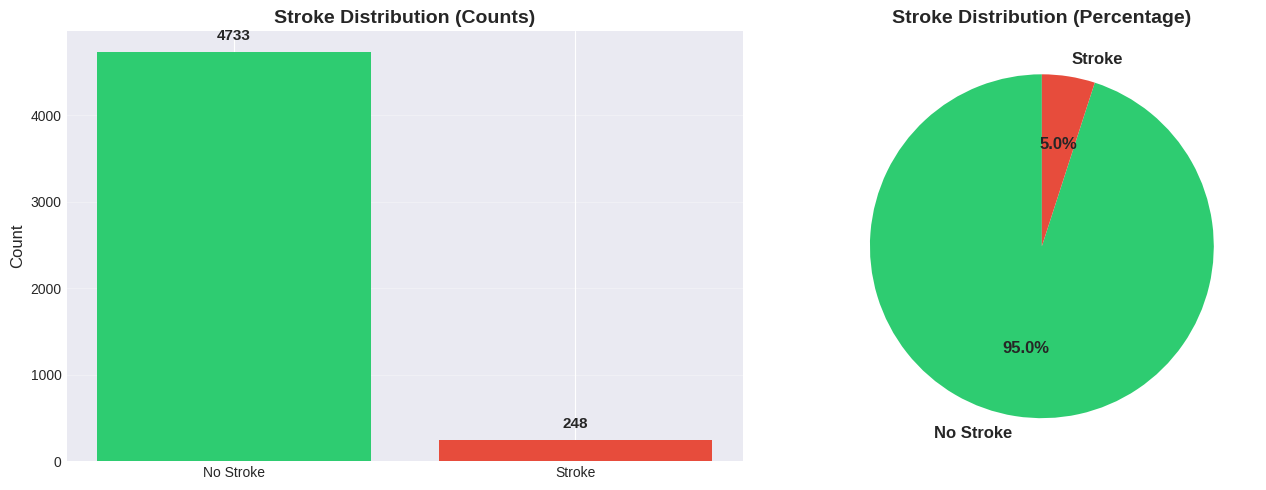

✓ Class imbalance detected - Stroke cases are only 4.98% of the data


In [ ]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Count plot
    stroke_counts = df['stroke'].value_counts()
    axes[0].bar(['No Stroke', 'Stroke'], stroke_counts.values, color=['#2ecc71', '#e74c3c'])
    axes[0].set_ylabel('Count', fontsize=12)
    axes[0].set_title('Stroke Distribution (Counts)', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)
    for i, v in enumerate(stroke_counts.values):
        axes[0].text(i, v + 100, str(v), ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Pie chart
    colors = ['#2ecc71', '#e74c3c']
    axes[1].pie(stroke_counts.values, labels=['No Stroke', 'Stroke'], autopct='%1.1f%%',
                startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
    axes[1].set_title('Stroke Distribution (Percentage)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    print(f"✓ Class imbalance detected - Stroke cases are only {(stroke_counts[1]/len(df)*100):.2f}% of the data")

### 3a.3 Numerical Features Distribution

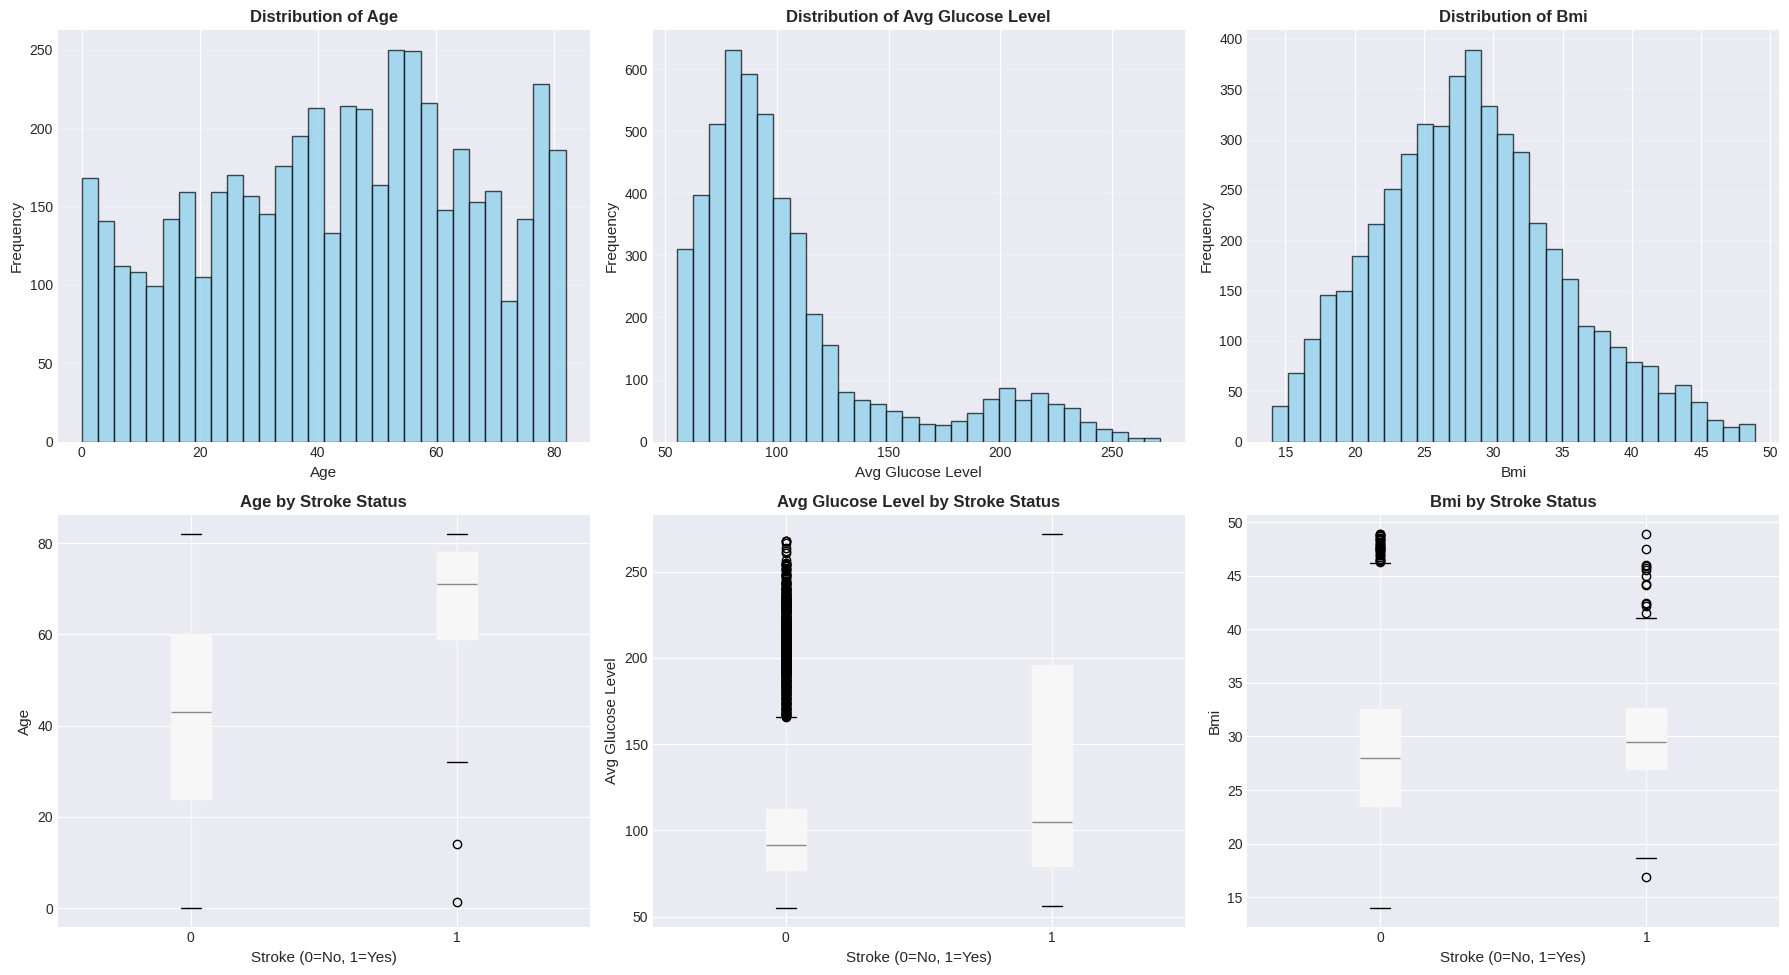

✓ Numerical features visualized


In [ ]:
if not df.empty:
    numerical_cols = ['age', 'avg_glucose_level', 'bmi']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    for idx, col in enumerate(numerical_cols):
        # Histograms
        axes[0, idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[0, idx].set_xlabel(col.replace('_', ' ').title(), fontsize=11)
        axes[0, idx].set_ylabel('Frequency', fontsize=11)
        axes[0, idx].set_title(f'Distribution of {col.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        axes[0, idx].grid(axis='y', alpha=0.3)

        # Box plots by stroke
        df.boxplot(column=col, by='stroke', ax=axes[1, idx], patch_artist=True)
        axes[1, idx].set_xlabel('Stroke (0=No, 1=Yes)', fontsize=11)
        axes[1, idx].set_ylabel(col.replace('_', ' ').title(), fontsize=11)
        axes[1, idx].set_title(f'{col.replace("_", " ").title()} by Stroke Status', fontsize=12, fontweight='bold')
        axes[1, idx].get_figure().suptitle('')  # Remove auto title

    plt.tight_layout()
    plt.show()

    print("✓ Numerical features visualized")

### 3a.4 Categorical Features Analysis

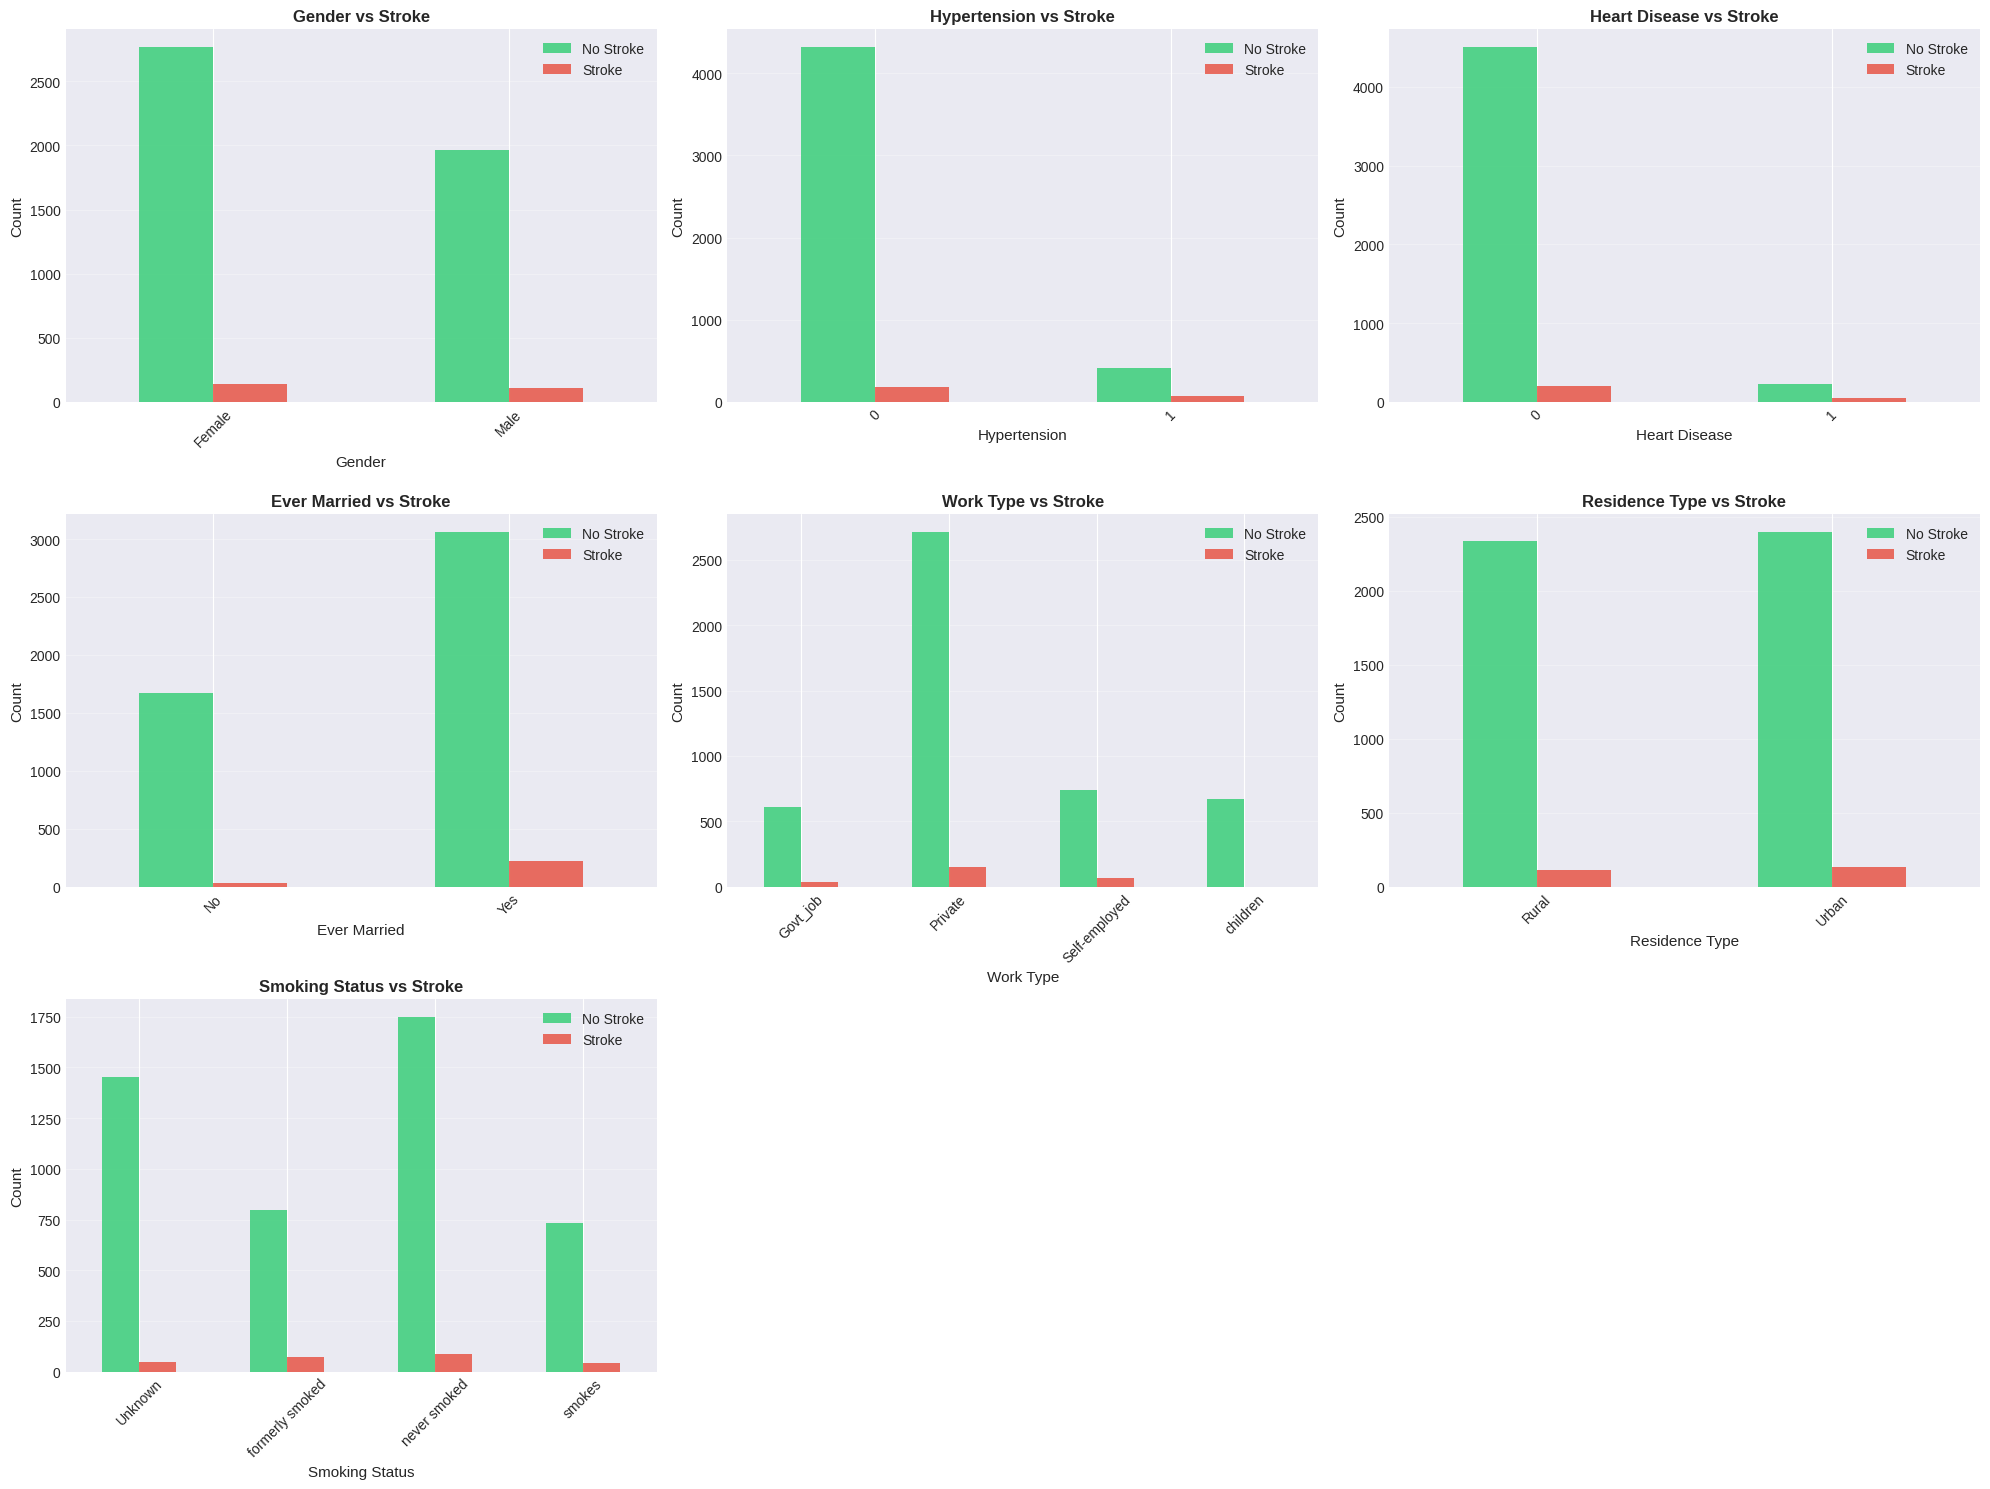

✓ Categorical features visualized


In [ ]:
if not df.empty:
    categorical_cols = ['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'smoking_status']

    fig, axes = plt.subplots(3, 3, figsize=(20, 15))
    axes = axes.flatten()

    for idx, col in enumerate(categorical_cols):
        # Count plot with stroke breakdown
        stroke_data = df.groupby([col, 'stroke']).size().unstack(fill_value=0)
        stroke_data.plot(kind='bar', ax=axes[idx], color=['#2ecc71', '#e74c3c'], alpha=0.8)
        axes[idx].set_xlabel(col.replace('_', ' ').title(), fontsize=11)
        axes[idx].set_ylabel('Count', fontsize=11)
        axes[idx].set_title(f'{col.replace("_", " ").title()} vs Stroke', fontsize=12, fontweight='bold')
        axes[idx].legend(['No Stroke', 'Stroke'], loc='best')
        axes[idx].grid(axis='y', alpha=0.3)
        axes[idx].tick_params(axis='x', rotation=45)

    # Remove extra subplots
    for idx in range(len(categorical_cols), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.show()

    print("✓ Categorical features visualized")

### 3a.5 Correlation Analysis

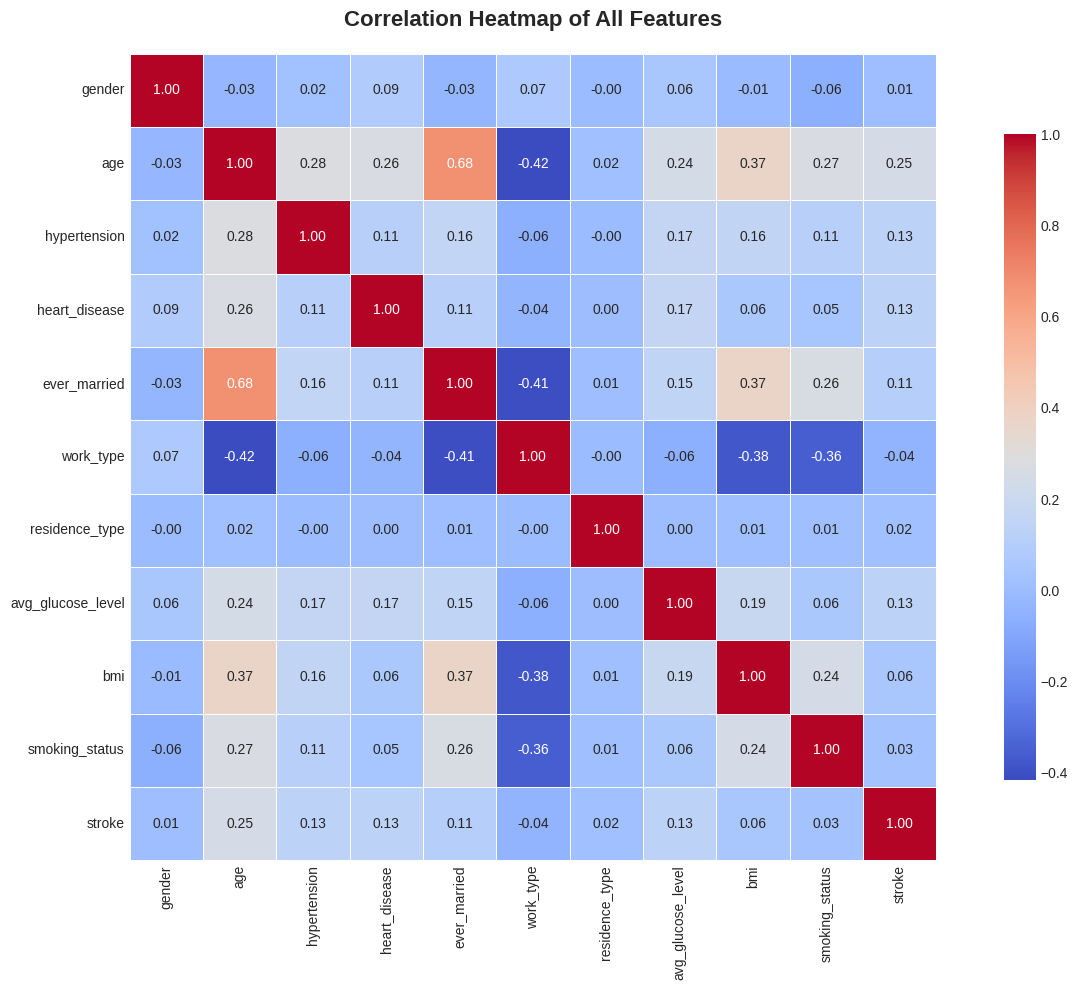


CORRELATIONS WITH STROKE (Target Variable)
stroke               1.000000
age                  0.246478
heart_disease        0.134610
avg_glucose_level    0.133227
hypertension         0.131965
ever_married         0.108398
bmi                  0.056926
smoking_status       0.027463
residence_type       0.016494
gender               0.008870
work_type           -0.041835
Name: stroke, dtype: float64

✓ Top positive correlations with stroke:
age                  0.246478
heart_disease        0.134610
avg_glucose_level    0.133227
Name: stroke, dtype: float64

✓ Top negative correlations with stroke:
work_type   -0.041835
Name: stroke, dtype: float64


In [ ]:
if not df.empty:
    # Create a copy for encoding
    df_encoded = df.copy()

    # Encode categorical variables for correlation
    le = LabelEncoder()
    categorical_cols = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
    for col in categorical_cols:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    # Compute correlation matrix
    correlation_matrix = df_encoded.corr()

    # Plot heatmap
    plt.figure(figsize=(14, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap of All Features', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.show()

    # Show correlations with stroke
    print("\n" + "="*60)
    print("CORRELATIONS WITH STROKE (Target Variable)")
    print("="*60)
    stroke_corr = correlation_matrix['stroke'].sort_values(ascending=False)
    print(stroke_corr)

    print("\n✓ Top positive correlations with stroke:")
    print(stroke_corr[stroke_corr > 0].iloc[1:4])  # Skip stroke itself

    print("\n✓ Top negative correlations with stroke:")
    print(stroke_corr[stroke_corr < 0].iloc[-3:])

### 3a.6 Age Analysis - Key Risk Factor

/tmp/ipython-input-42454162.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_stroke_rate = df.groupby('age_group')['stroke'].mean() * 100
/tmp/ipython-input-42454162.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='stroke', y='age', ax=axes[2], palette=['#2ecc71', '#e74c3c'])


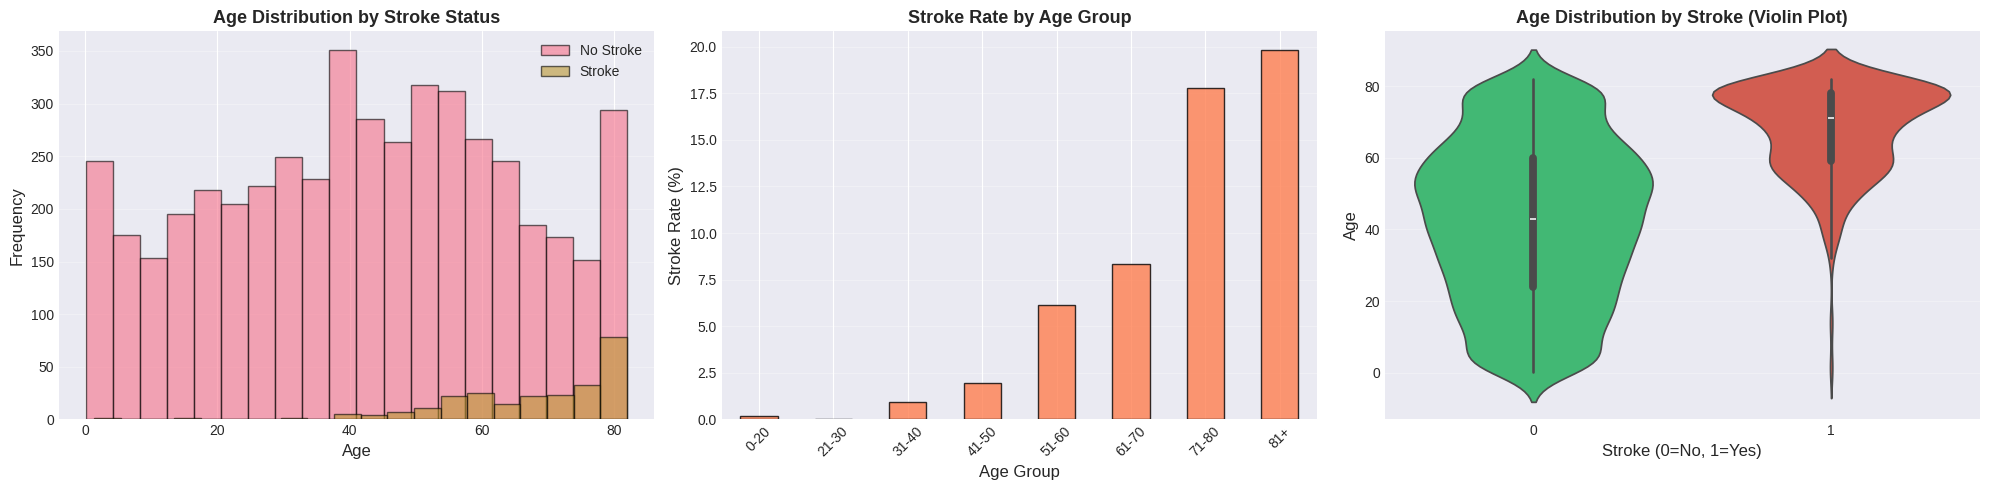


AGE STATISTICS BY STROKE STATUS
         count       mean        std   min   25%   50%   75%   max
stroke                                                            
0       4733.0  42.141348  22.345036  0.08  24.0  43.0  60.0  82.0
1        248.0  67.819839  12.670565  1.32  59.0  71.0  78.0  82.0


In [ ]:
if not df.empty:
    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Age distribution by stroke
    for stroke_val in [0, 1]:
        data = df[df['stroke'] == stroke_val]['age']
        axes[0].hist(data, bins=20, alpha=0.6, label=f'Stroke={stroke_val}', edgecolor='black')
    axes[0].set_xlabel('Age', fontsize=12)
    axes[0].set_ylabel('Frequency', fontsize=12)
    axes[0].set_title('Age Distribution by Stroke Status', fontsize=13, fontweight='bold')
    axes[0].legend(['No Stroke', 'Stroke'])
    axes[0].grid(axis='y', alpha=0.3)

    # Stroke rate by age group
    df['age_group'] = pd.cut(df['age'], bins=[0, 20, 30, 40, 50, 60, 70, 80, 100],
                              labels=['0-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81+'])
    age_stroke_rate = df.groupby('age_group')['stroke'].mean() * 100
    age_stroke_rate.plot(kind='bar', ax=axes[1], color='coral', edgecolor='black', alpha=0.8)
    axes[1].set_xlabel('Age Group', fontsize=12)
    axes[1].set_ylabel('Stroke Rate (%)', fontsize=12)
    axes[1].set_title('Stroke Rate by Age Group', fontsize=13, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].grid(axis='y', alpha=0.3)

    # Violin plot
    sns.violinplot(data=df, x='stroke', y='age', ax=axes[2], palette=['#2ecc71', '#e74c3c'])
    axes[2].set_xlabel('Stroke (0=No, 1=Yes)', fontsize=12)
    axes[2].set_ylabel('Age', fontsize=12)
    axes[2].set_title('Age Distribution by Stroke (Violin Plot)', fontsize=13, fontweight='bold')
    axes[2].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print("\n" + "="*60)
    print("AGE STATISTICS BY STROKE STATUS")
    print("="*60)
    print(df.groupby('stroke')['age'].describe())

## 4. Data Preprocessing

Steps:
- Handle missing values with median imputation
- Encode categorical variables
- Scale features using StandardScaler

In [ ]:
def preprocess_data(df: pd.DataFrame):
    """Preprocess and encode categorical variables"""
    df = df.copy()

    if df.empty:
        raise ValueError("No data available to train the model.")

    # Drop 'age_group' column if it exists, as it was created for EDA and is not numeric for scaling
    if 'age_group' in df.columns:
        df = df.drop('age_group', axis=1)

    # Basic NA handling for numeric columns (median fill)
    numeric_cols = ['age', 'avg_glucose_level', 'bmi']
    for col in numeric_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    # Encode categorical columns
    le = LabelEncoder()
    categorical_columns = ['gender', 'ever_married', 'work_type', 'residence_type', 'smoking_status']
    for col in categorical_columns:
        if col in df.columns:
            df[col] = df[col].astype(str)
            df[col] = le.fit_transform(df[col])

    # Features/target split
    X = df.drop('stroke', axis=1)
    y = df['stroke'].astype(int)

    # Scale features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return X_scaled, y, scaler, list(X.columns)

print("✓ Preprocessing function defined")

✓ Preprocessing function defined


In [ ]:
# Preprocess the data
if not df.empty:
    X, y, scaler, feature_names = preprocess_data(df)
    print(f"✓ Data preprocessed")
    print(f"Features shape: {X.shape}")
    print(f"Target shape: {y.shape}")
    print(f"\nFeature names: {feature_names}")
else:
    print("⚠ Cannot preprocess empty dataframe")

✓ Data preprocessed
Features shape: (4981, 10)
Target shape: (4981,)

Feature names: ['gender', 'age', 'hypertension', 'heart_disease', 'ever_married', 'work_type', 'residence_type', 'avg_glucose_level', 'bmi', 'smoking_status']


## 5. Train-Test Split

Using stratified split to maintain class balance in both sets.

In [ ]:
if not df.empty:
    # Stratified train/test split to maintain balance
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    for train_idx, test_idx in sss.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # Validate both sets contain both classes
    assert y_train.nunique() > 1 and y_test.nunique() > 1, "Train/test must contain both classes."

    print(f"✓ Data split completed")
    print(f"Training set size: {X_train.shape[0]} samples")
    print(f"Test set size: {X_test.shape[0]} samples")
    print(f"\nTraining set class distribution:")
    print(y_train.value_counts())
    print(f"\nTest set class distribution:")
    print(y_test.value_counts())
else:
    print("⚠ Cannot split empty dataframe")

✓ Data split completed
Training set size: 3984 samples
Test set size: 997 samples

Training set class distribution:
stroke
0    3786
1     198
Name: count, dtype: int64

Test set class distribution:
stroke
0    947
1     50
Name: count, dtype: int64


## 6. Train Random Forest Model

Configuration:
- 200 estimators (trees)
- Unlimited max depth
- Balanced class weights to handle imbalance
- All CPU cores for parallel processing

In [ ]:
def train_random_forest(X_train, y_train):
    """Train Random Forest classifier."""
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'  # handle potential class imbalance
    )
    model.fit(X_train, y_train)
    return model

print("✓ Training function defined")

✓ Training function defined


In [ ]:
if not df.empty:
    print("Training Random Forest model...")
    rf_model = train_random_forest(X_train, y_train)
    print("✓ Model training completed")
else:
    print("⚠ Cannot train on empty dataframe")

Training Random Forest model...
✓ Model training completed


## 7. Model Evaluation

Compute comprehensive metrics:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- Confusion Matrix
- Classification Report

In [ ]:
def evaluate_model(model, X_test, y_test):
    """Compute clear evaluation metrics for the classifier."""
    y_pred = model.predict(X_test)

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
        'classification_report': classification_report(y_test, y_pred, zero_division=0)
    }

    if hasattr(model, 'predict_proba'):
        classes = getattr(model, 'classes_', None)
        if classes is not None and len(classes) > 1:
            # pick probability of class 1 if present, else map accordingly
            idx = int(np.where(classes == 1)[0][0]) if 1 in classes else 1
            y_proba = model.predict_proba(X_test)[:, idx]
            try:
                metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
            except ValueError:
                metrics['roc_auc'] = None
        else:
            metrics['roc_auc'] = None
    else:
        metrics['roc_auc'] = None

    return metrics

print("✓ Evaluation function defined")

✓ Evaluation function defined


In [ ]:
if not df.empty:
    print("Evaluating model...")
    metrics = evaluate_model(rf_model, X_test, y_test)
    print("✓ Evaluation completed")
else:
    print("⚠ Cannot evaluate without data")

Evaluating model...
✓ Evaluation completed


## 8. Model Evaluation Results

Comprehensive evaluation with visualizations and detailed metrics.

In [ ]:
if not df.empty:
    print("\n" + "="*70)
    print("RANDOM FOREST EVALUATION METRICS")
    print("="*70)
    print(f"Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
    print(f"Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)")
    print(f"Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)")
    print(f"F1-Score:  {metrics['f1_score']:.4f}")
    if metrics['roc_auc'] is not None:
        print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")

    print("\n" + "="*70)
    print("CONFUSION MATRIX")
    print("="*70)
    cm = metrics['confusion_matrix']
    print(f"True Negatives (TN):  {cm[0][0]:4d} | Correctly predicted No Stroke")
    print(f"False Positives (FP): {cm[0][1]:4d} | Incorrectly predicted Stroke")
    print(f"False Negatives (FN): {cm[1][0]:4d} | Incorrectly predicted No Stroke")
    print(f"True Positives (TP):  {cm[1][1]:4d} | Correctly predicted Stroke")

    print("\n" + "="*70)
    print("CLASSIFICATION REPORT")
    print("="*70)
    print(metrics['classification_report'])


RANDOM FOREST EVALUATION METRICS
Accuracy:  0.9478 (94.78%)
Precision: 0.0000 (0.00%)
Recall:    0.0000 (0.00%)
F1-Score:  0.0000
ROC-AUC:   0.8159

CONFUSION MATRIX
True Negatives (TN):   945 | Correctly predicted No Stroke
False Positives (FP):    2 | Incorrectly predicted Stroke
False Negatives (FN):   50 | Incorrectly predicted No Stroke
True Positives (TP):     0 | Correctly predicted Stroke

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       947
           1       0.00      0.00      0.00        50

    accuracy                           0.95       997
   macro avg       0.47      0.50      0.49       997
weighted avg       0.90      0.95      0.92       997



### 8.1 Confusion Matrix Visualization

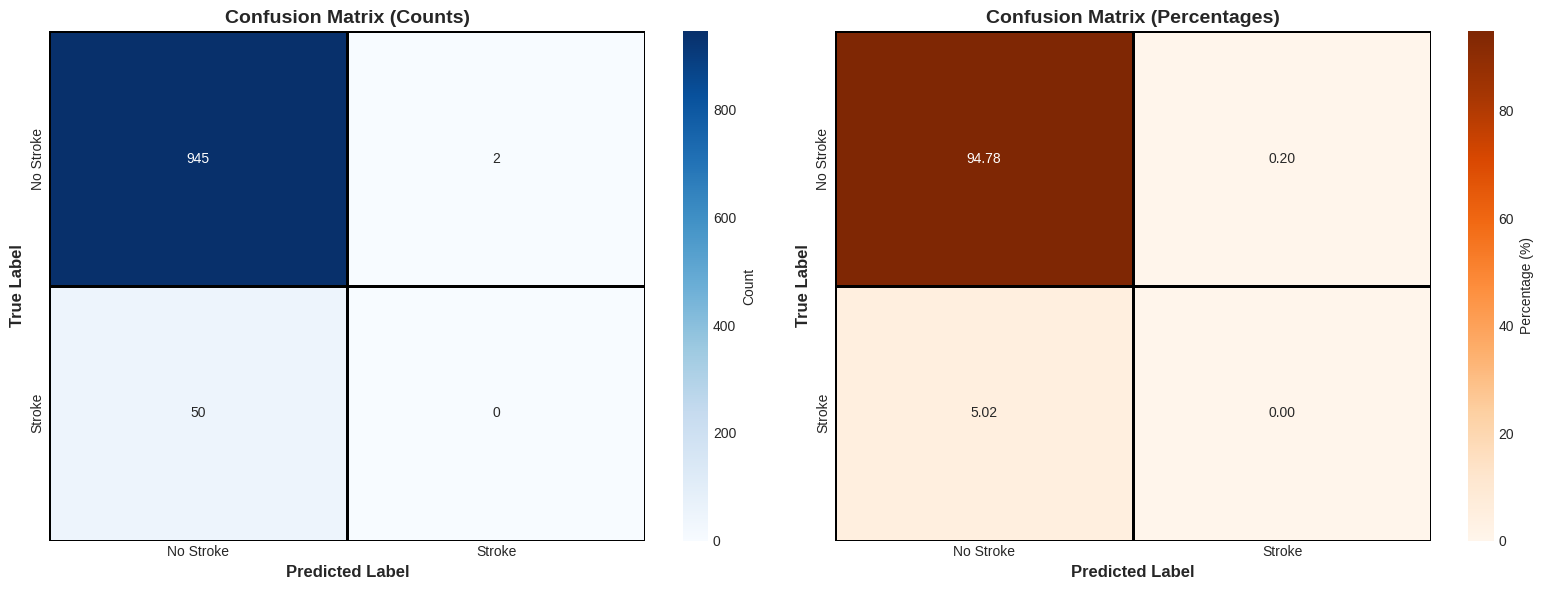

In [ ]:
if not df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Confusion matrix heatmap (counts)
    cm = np.array(metrics['confusion_matrix'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                cbar_kws={'label': 'Count'}, linewidths=2, linecolor='black')
    axes[0].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')

    # Confusion matrix heatmap (percentages)
    cm_percent = cm.astype('float') / cm.sum() * 100
    sns.heatmap(cm_percent, annot=True, fmt='.2f', cmap='Oranges', ax=axes[1],
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'],
                cbar_kws={'label': 'Percentage (%)'}, linewidths=2, linecolor='black')
    axes[1].set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('True Label', fontsize=12, fontweight='bold')
    axes[1].set_title('Confusion Matrix (Percentages)', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

### 8.2 ROC Curve and AUC Score

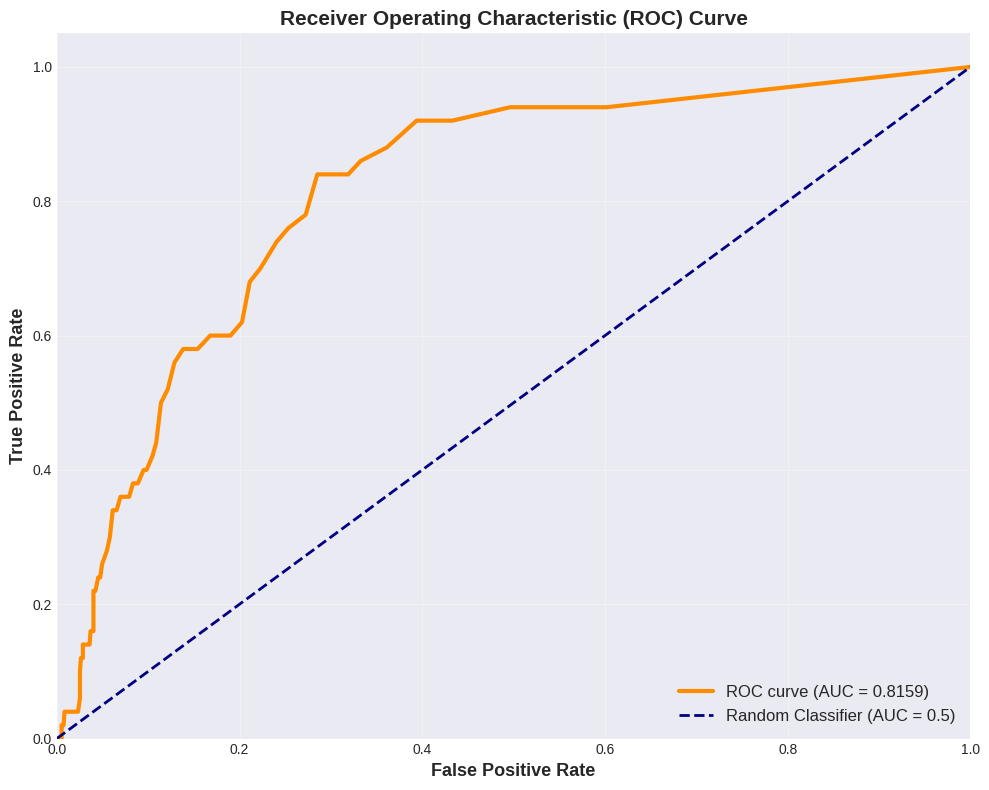

✓ ROC-AUC Score: 0.8159
✓ Model performs 63.2% better than random guessing


In [ ]:
if not df.empty:
    if hasattr(rf_model, 'predict_proba'):
        # Get predicted probabilities
        y_proba = rf_model.predict_proba(X_test)[:, 1]

        # Calculate ROC curve
        fpr, tpr, thresholds = roc_curve(y_test, y_proba)
        roc_auc = roc_auc_score(y_test, y_proba)

        # Plot ROC curve
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier (AUC = 0.5)')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
        plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
        plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=15, fontweight='bold')
        plt.legend(loc="lower right", fontsize=12)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"✓ ROC-AUC Score: {roc_auc:.4f}")
        print(f"✓ Model performs {((roc_auc - 0.5) / 0.5 * 100):.1f}% better than random guessing")

### 8.3 Performance Metrics Comparison

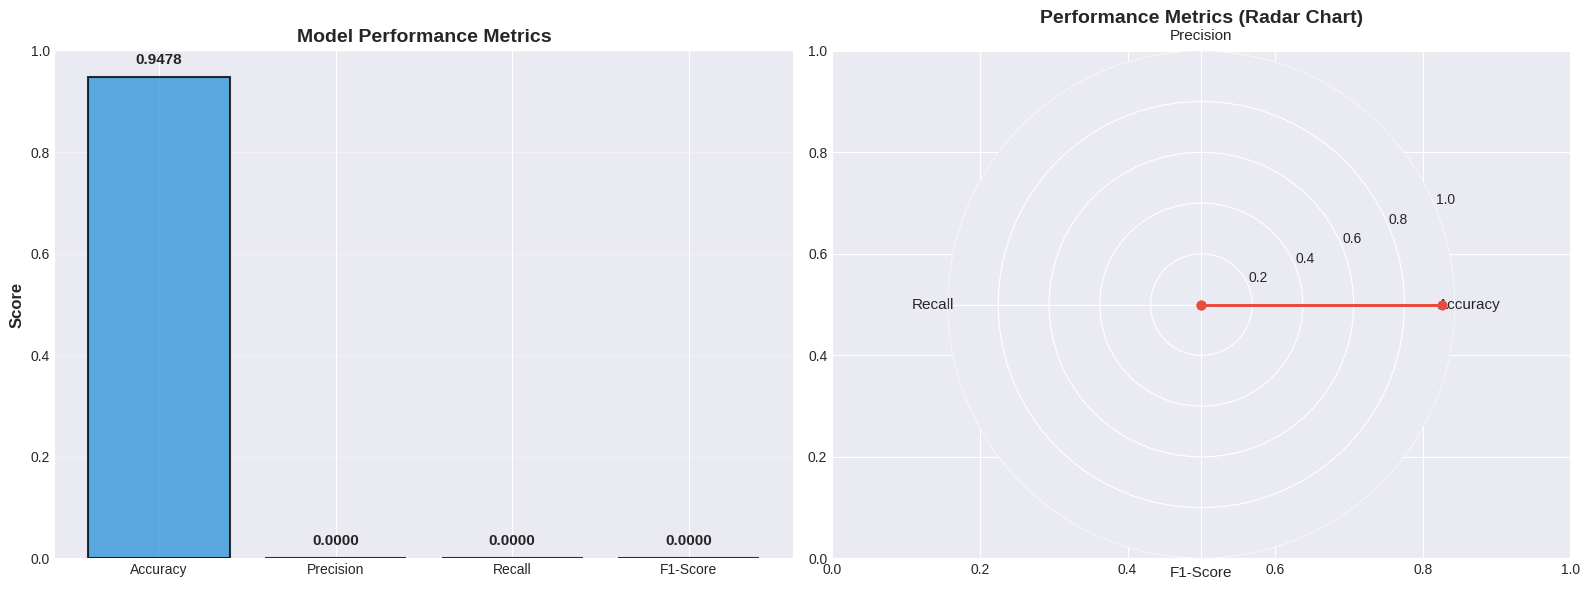

In [ ]:
if not df.empty:
    # Create metrics comparison chart
    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
    metrics_values = [
        metrics['accuracy'],
        metrics['precision'],
        metrics['recall'],
        metrics['f1_score']
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart
    bars = axes[0].bar(metrics_names, metrics_values, color=['#3498db', '#e74c3c', '#2ecc71', '#f39c12'],
                       edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0].set_ylabel('Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Model Performance Metrics', fontsize=14, fontweight='bold')
    axes[0].set_ylim([0, 1])
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels on bars
    for bar, value in zip(bars, metrics_values):
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{value:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

    # Radar chart
    angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist()
    metrics_values_radar = metrics_values + [metrics_values[0]]  # Close the plot
    angles += angles[:1]

    ax = plt.subplot(122, polar=True)
    ax.plot(angles, metrics_values_radar, 'o-', linewidth=2, color='#e74c3c')
    ax.fill(angles, metrics_values_radar, alpha=0.25, color='#e74c3c')
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(metrics_names, fontsize=11)
    ax.set_ylim(0, 1)
    ax.set_title('Performance Metrics (Radar Chart)', fontsize=14, fontweight='bold', pad=20)
    ax.grid(True)

    plt.tight_layout()
    plt.show()

## 9. Cross-Validation

Perform 5-fold cross-validation to assess model stability.

Performing 5-Fold Cross-Validation on training set...

CROSS-VALIDATION RESULTS
Fold 1: 0.9511
Fold 2: 0.9486
Fold 3: 0.9498
Fold 4: 0.9498
Fold 5: 0.9485

Mean CV Score: 0.9495 ± 0.0010


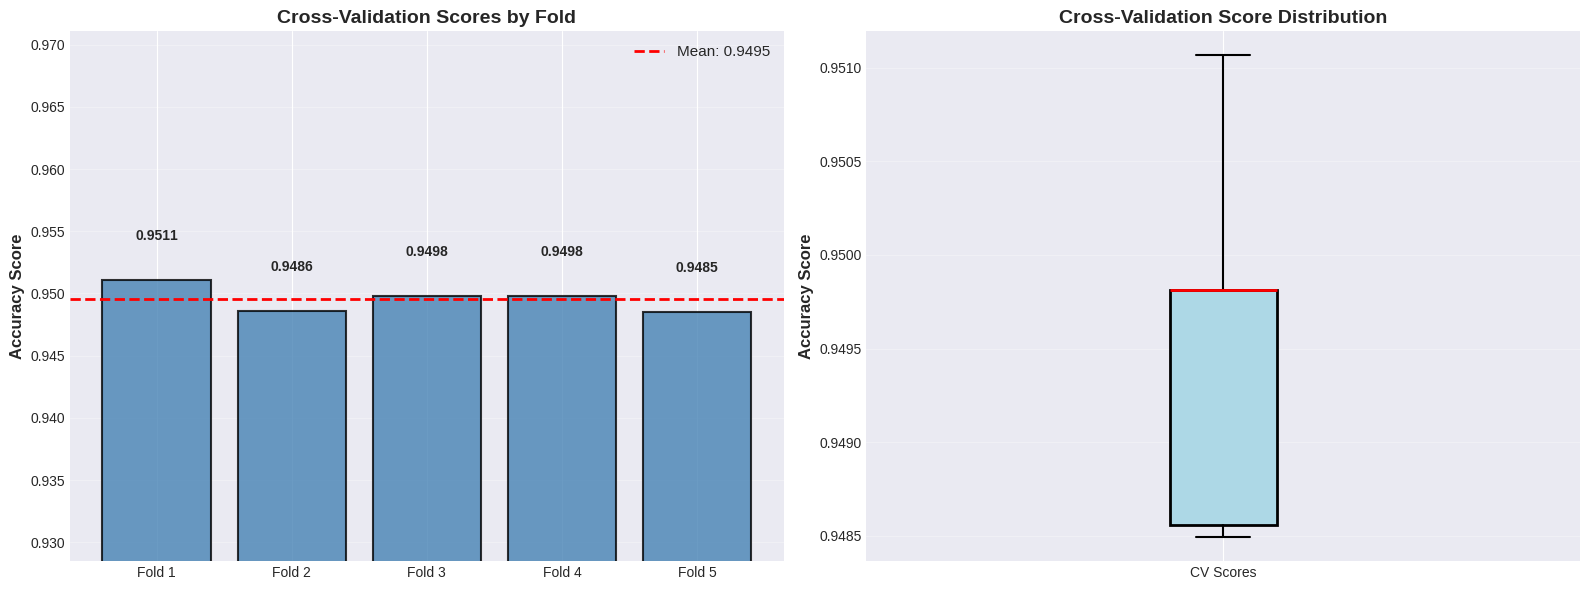


✓ Model shows consistent performance across folds


In [ ]:
if not df.empty:
    print("Performing 5-Fold Cross-Validation on training set...")
    cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='accuracy')

    print("\n" + "="*60)
    print("CROSS-VALIDATION RESULTS")
    print("="*60)
    for i, score in enumerate(cv_scores, 1):
        print(f"Fold {i}: {score:.4f}")
    print(f"\nMean CV Score: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # Visualize CV scores
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Bar chart of fold scores
    folds = [f'Fold {i}' for i in range(1, 6)]
    axes[0].bar(folds, cv_scores, color='steelblue', edgecolor='black', linewidth=1.5, alpha=0.8)
    axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
    axes[0].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
    axes[0].set_title('Cross-Validation Scores by Fold', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(axis='y', alpha=0.3)
    axes[0].set_ylim([cv_scores.min() - 0.02, cv_scores.max() + 0.02])

    # Add value labels
    for i, (fold, score) in enumerate(zip(folds, cv_scores)):
        axes[0].text(i, score + 0.003, f'{score:.4f}', ha='center', va='bottom',
                    fontsize=10, fontweight='bold')

    # Box plot
    axes[1].boxplot(cv_scores, vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightblue', color='black', linewidth=2),
                   medianprops=dict(color='red', linewidth=2),
                   whiskerprops=dict(color='black', linewidth=1.5),
                   capprops=dict(color='black', linewidth=1.5))
    axes[1].set_ylabel('Accuracy Score', fontsize=12, fontweight='bold')
    axes[1].set_title('Cross-Validation Score Distribution', fontsize=14, fontweight='bold')
    axes[1].set_xticklabels(['CV Scores'])
    axes[1].grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n✓ Model shows {'consistent' if cv_scores.std() < 0.02 else 'variable'} performance across folds")

## 10. Feature Importance Analysis

Identify the most important features for stroke prediction.


FEATURE IMPORTANCES
age                       0.3732 █████████████████████████████████████
avg_glucose_level         0.2115 █████████████████████
bmi                       0.1886 ██████████████████
smoking_status            0.0498 ████
work_type                 0.0452 ████
hypertension              0.0358 ███
ever_married              0.0339 ███
gender                    0.0222 ██
residence_type            0.0215 ██
heart_disease             0.0184 █


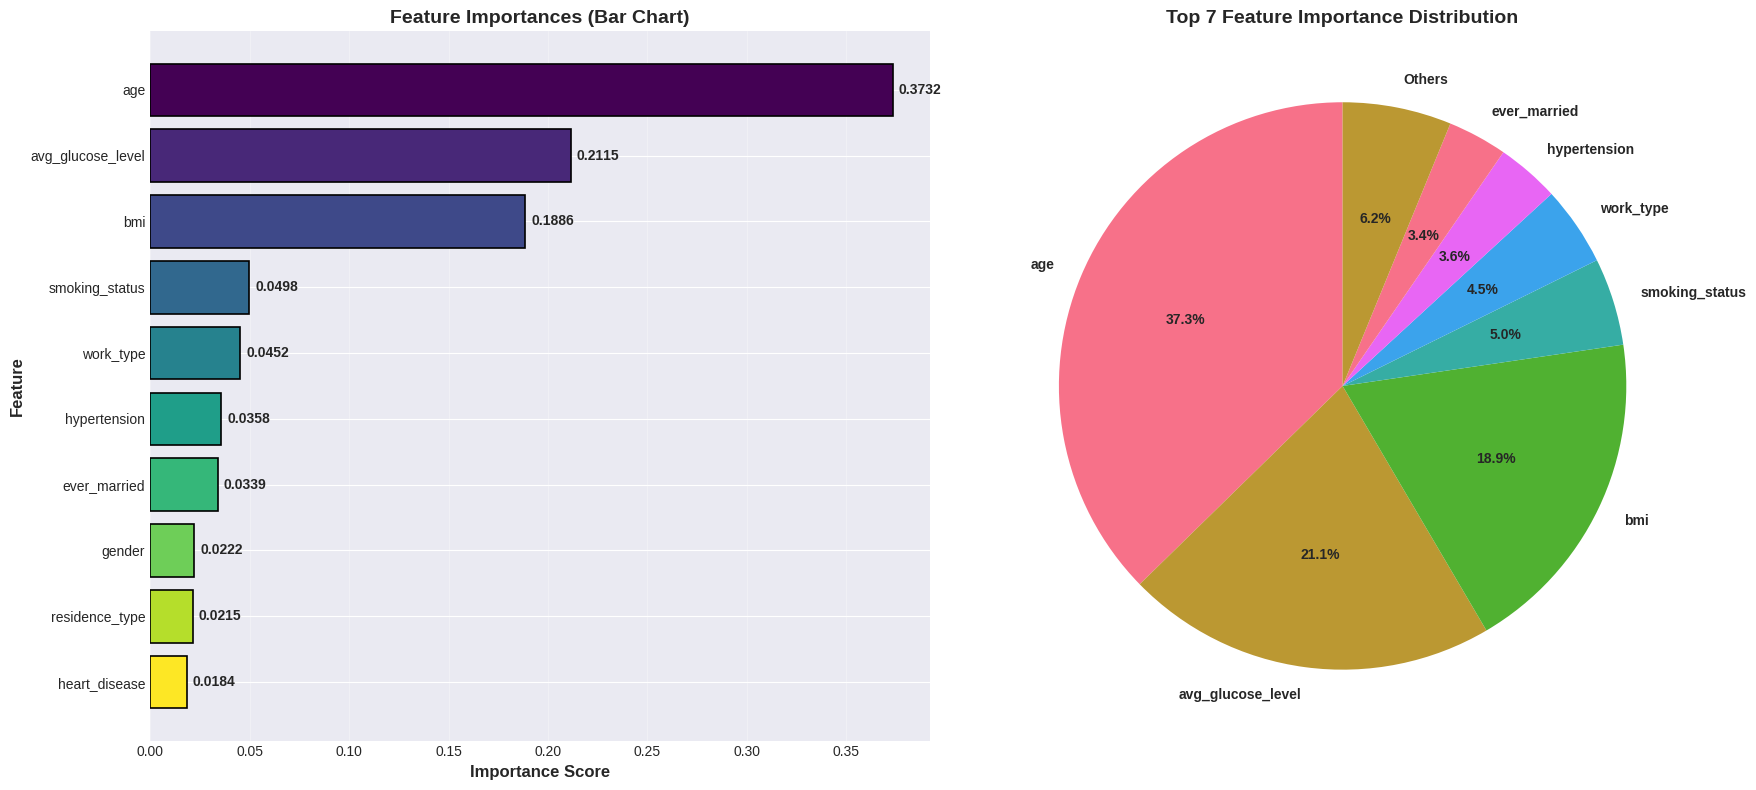


✓ Top 3 most important features:
  1. age: 0.3732
  2. avg_glucose_level: 0.2115
  3. bmi: 0.1886


In [ ]:
if not df.empty:
    if hasattr(rf_model, 'feature_importances_'):
        importances = rf_model.feature_importances_
        pairs = sorted(zip(feature_names, importances), key=lambda x: x[1], reverse=True)

        print("\n" + "="*70)
        print("FEATURE IMPORTANCES")
        print("="*70)
        for name, val in pairs:
            print(f"{name:25s} {val:.4f} {'█' * int(val * 100)}")

        # Create visualizations
        feature_imp_df = pd.DataFrame(pairs, columns=['Feature', 'Importance'])

        fig, axes = plt.subplots(1, 2, figsize=(18, 8))

        # Horizontal bar chart
        colors = plt.cm.viridis(np.linspace(0, 1, len(feature_imp_df)))
        axes[0].barh(feature_imp_df['Feature'], feature_imp_df['Importance'],
                     color=colors, edgecolor='black', linewidth=1.2)
        axes[0].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
        axes[0].set_ylabel('Feature', fontsize=12, fontweight='bold')
        axes[0].set_title('Feature Importances (Bar Chart)', fontsize=14, fontweight='bold')
        axes[0].invert_yaxis()
        axes[0].grid(axis='x', alpha=0.3)

        # Add value labels
        for idx, (feature, importance) in enumerate(zip(feature_imp_df['Feature'], feature_imp_df['Importance'])):
            axes[0].text(importance + 0.003, idx, f'{importance:.4f}',
                        va='center', fontsize=10, fontweight='bold')

        # Pie chart for top features
        top_n = 7
        top_features = feature_imp_df.head(top_n)
        other_importance = feature_imp_df.iloc[top_n:]['Importance'].sum() if len(feature_imp_df) > top_n else 0

        if other_importance > 0:
            labels = list(top_features['Feature']) + ['Others']
            sizes = list(top_features['Importance']) + [other_importance]
        else:
            labels = list(top_features['Feature'])
            sizes = list(top_features['Importance'])

        axes[1].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
                   textprops={'fontsize': 10, 'fontweight': 'bold'})
        axes[1].set_title(f'Top {top_n} Feature Importance Distribution', fontsize=14, fontweight='bold')

        plt.tight_layout()
        plt.show()

        print(f"\n✓ Top 3 most important features:")
        for i, (name, val) in enumerate(pairs[:3], 1):
            print(f"  {i}. {name}: {val:.4f}")

## 11. Discussion

_This section is intended for a detailed narrative interpretation of the results, implications of findings, model limitations, and future work. Here are some points you might consider:

*   **Summary of Key Findings**: Briefly reiterate the most important results from your EDA, model performance, and feature importance.
*   **Interpretation of Model Performance**: Discuss the achieved accuracy, precision, recall, F1-score, and ROC-AUC. Given the class imbalance, specifically address the performance on the minority class (stroke cases). Why is precision low? What does a high ROC-AUC indicate despite low precision/recall for the positive class?
*   **Insights from Feature Importance**: Elaborate on why `age`, `avg_glucose_level`, and `bmi` are the most critical predictors. Relate these to existing medical knowledge if possible.
*   **Model Limitations**: Acknowledge the weaknesses of the current model. For example, the difficulty in correctly identifying stroke cases (high False Negatives) due to extreme class imbalance. Are there other features that could improve the model?
*   **Potential Biases**: Discuss any potential biases in the dataset or model. For instance, the gender distribution or representation of different demographics.
*   **Comparison to Baseline/Literature**: If applicable, compare your model's performance to simple baselines or similar studies.
*   **Ethical Considerations**: Briefly touch upon the implications of deploying such a system, especially considering false negatives (missing actual stroke cases) and false positives (unnecessary panic/tests).
*   **Suggestions for Future Work**: What could be done next? (e.g., using more advanced techniques for imbalanced data, collecting more balanced data, hyperparameter tuning, trying different models, ensemble methods, explainable AI techniques)._

## 12. Conclusion

_This section should provide a concise summary of the entire project, highlighting the main achievements and reiterating the core message or takeaway. It should briefly answer the question: What have we learned or accomplished?_